# IF3270 Machine Learning | Tubes 2 - CNN

## Intel Image Classification

Anggota Kelompok:
1. Albertus Christian Poandy (13523077)
2. Grace Evelyn Simon (13523087)
3. Karol Yangqian Poetracahya (13523093)

## Import Libraries

In [1]:
import os
import sys
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import tf_keras

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from pathlib import Path

REPO_BASE = Path('../..').resolve()
sys.path.append(str(REPO_BASE / 'src'))

from scratchlayers.cnn.cnn import (
    Conv2DScratch, LocallyConnected2DScratch,
    MaxPooling2DScratch, AveragePooling2DScratch,
    FlattenScratch
)
from scratchlayers.dense.dense import Dense
from scratchlayers.core.sequential import Sequential
from scratchlayers.cnn.utils import load_image, load_batch

SEED = 42
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_reproducibility(SEED)

I0000 00:00:1778938897.948109    2117 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Import Dataset

Memuat dataset Intel Image Classification dan memahami karakteristik datanya sebelum pemodelan dimulai. Dataset dibagi menjadi split train, validation, dan test yang sudah tersedia.

In [2]:
DATASET_BASE = REPO_BASE / 'dataset'
print('Dataset path:', DATASET_BASE.resolve())
print('Exists:', DATASET_BASE.exists())

Dataset path: /mnt/d/ObsidianVault/Semester 6/IF3270 Pembelajaran Mesin/Tugas/TUBES/Tubes2-ML/dataset
Exists: True


In [3]:
TRAIN_DIR   = str(DATASET_BASE / 'seg_train' / 'seg_train')
TEST_DIR    = str(DATASET_BASE / 'seg_test'  / 'seg_test')
WEIGHTS_DIR = REPO_BASE / 'weights' / 'cnn3'
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE  = (64, 64)
BATCH_SIZE  = 32
EPOCHS      = 10
NUM_CLASSES = 6
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

SAMPLE_TRAIN_BATCHES = 50
SAMPLE_VAL_BATCHES   = 15

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
).map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)).take(SAMPLE_TRAIN_BATCHES)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
).map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)).take(SAMPLE_VAL_BATCHES)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
).map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

print('Train batches:', len(train_ds))
print('Val batches  :', len(val_ds))
print('Test batches :', len(test_ds))

Found 4618 files belonging to 6 classes.
Using 3695 files for training.


I0000 00:00:1778938904.750868    2117 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 4618 files belonging to 6 classes.
Using 923 files for validation.
Found 3000 files belonging to 6 classes.
Train batches: 50
Val batches  : 15
Test batches : 94


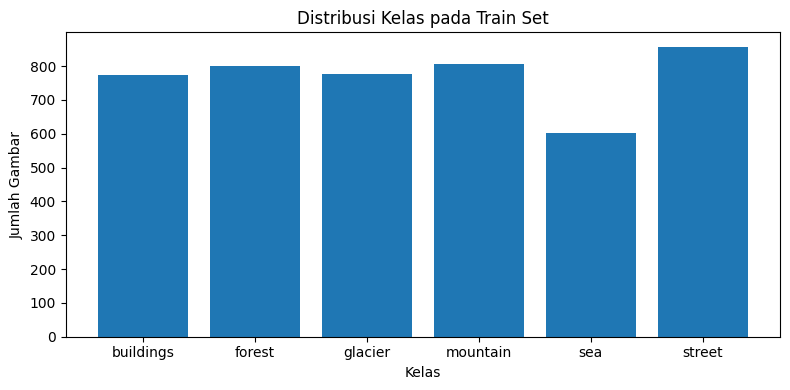

buildings   :   775 (16.8%)
forest      :   801 (17.3%)
glacier     :   778 (16.8%)
mountain    :   805 (17.4%)
sea         :   602 (13.0%)
street      :   857 (18.6%)


In [4]:
# Distribusi kelas pada data train
class_counts = {cls: 0 for cls in CLASS_NAMES}
for cls in CLASS_NAMES:
    class_counts[cls] = len(list(Path(TRAIN_DIR).glob(f'{cls}/*')))

plt.figure(figsize=(8, 4))
x_labels = list(class_counts.keys())
y_counts = list(class_counts.values())
plt.bar(x_labels, y_counts)
plt.title('Distribusi Kelas pada Train Set')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

total = sum(class_counts.values())
for cls, cnt in class_counts.items():
    print(f'{cls:12s}: {cnt:5d} ({cnt/total*100:.1f}%)')

Insight:

Dataset train terdiri dari 14.034 gambar yang terbagi ke dalam 6 kelas. Distribusi kelas menunjukkan bahwa data relatif seimbang, dengan proporsi tiap kelas berkisar antara 15,6% hingga 17,9%. Kelas mountain memiliki jumlah sampel terbanyak (2.512 gambar, 17,9%), diikuti oleh glacier (2.404, 17,1%), street (2.382, 17,0%), sea (2.274, 16,2%), forest (2.271, 16,2%), dan buildings sebagai kelas dengan jumlah terkecil (2.191 gambar, 15,6%). Dengan selisih proporsi antar kelas yang sangat kecil, dataset ini tidak mengalami masalah class imbalance yang signifikan, sehingga metrik evaluasi seperti macro F1-score dapat digunakan secara langsung tanpa perlu teknik resampling atau pembobotan kelas tambahan.

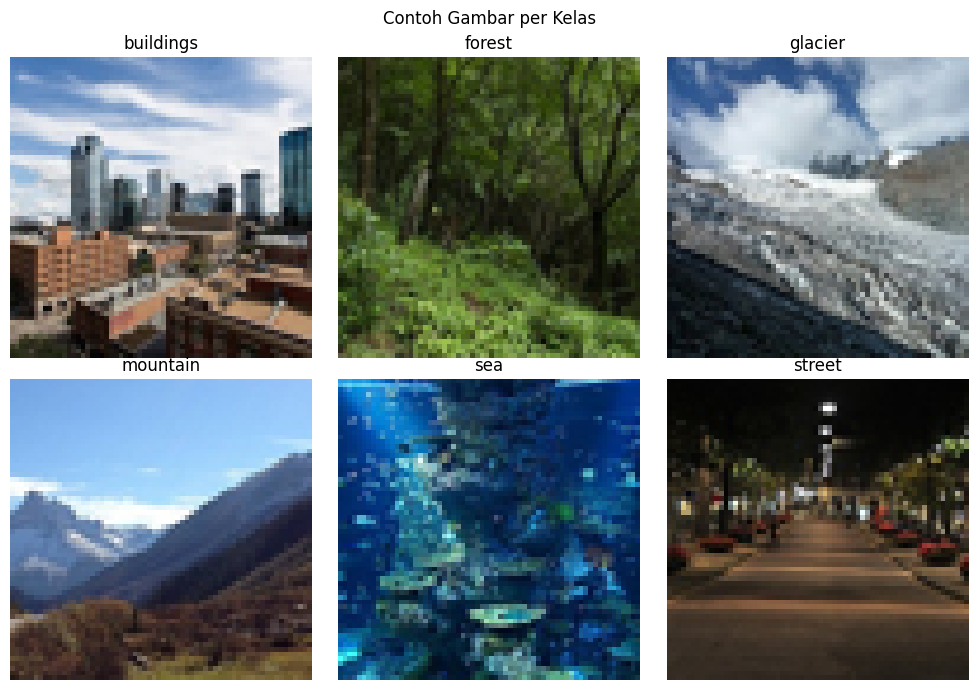

In [5]:
# Contoh gambar per kelas
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, cls in zip(axes.flat, CLASS_NAMES):
    img_path = next(Path(TRAIN_DIR).glob(f'{cls}/*.jpg'))
    img = load_image(str(img_path), target_size=IMAGE_SIZE)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle('Contoh Gambar per Kelas')
plt.tight_layout()
plt.show()

Insight:

Untuk memahami karakteristik visual masing-masing kelas, ditampilkan satu contoh gambar representatif dari setiap kategori dalam dataset. Keberagaman tampilan visual ini mengindikasikan bahwa model CNN diharapkan mampu mengekstrak fitur-fitur tekstur, warna, dan bentuk yang berbeda untuk setiap kelas.

# 2. Data Cleaning and Preprocessing

Bagian ini bertujuan memastikan data gambar dalam format dan rentang nilai yang sesuai untuk diproses oleh model CNN. Dilakukan pengecekan shape dan rentang nilai piksel hasil normalisasi, serta pengujian fungsi image loader dan batch loader yang diimplementasikan menggunakan PIL dan NumPy.

In [6]:
sample_path = next(Path(TRAIN_DIR).glob('buildings/*.jpg'))
img = load_image(str(sample_path), target_size=IMAGE_SIZE)
print('Shape :', img.shape)
print('Min   :', img.min(), '  Max:', img.max())

Shape : (64, 64, 3)
Min   : 0.0   Max: 0.9882353


In [7]:
sample_paths = [str(p) for cls in CLASS_NAMES for p in list(Path(TRAIN_DIR).glob(f'{cls}/*.jpg'))[:2]]
batch = load_batch(sample_paths, target_size=IMAGE_SIZE)
print('Batch shape:', batch.shape)

Batch shape: (12, 64, 64, 3)


# 3. Modeling and Validation
## Pelatihan 16 Arsitektur
Grid hyperparameter:
- n_layers: jumlah layer konvolusi (`[2, 4]`)
- filters: filter per layer (`[[32, 64], [64, 128]]`)
- kernel_size: ukuran filter (`[3, 5]`)
- pooling: jenis pooling (`['max', 'avg']`)

Mengeksplorasi pengaruh berbagai hyperparameter terhadap performa model CNN. Seluruh model dievaluasi menggunakan macro F1-score pada data validasi dan test, lalu bobotnya disimpan untuk digunakan pada tahap berikutnya.

In [8]:
def build_cnn(n_layers, filters, kernel_size, pooling):
    filters_ext = (filters * n_layers)[:n_layers]
    Pool = keras.layers.MaxPooling2D if pooling == 'max' else keras.layers.AveragePooling2D

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(*IMAGE_SIZE, 3)))
    for i in range(n_layers):
        model.add(keras.layers.Conv2D(filters_ext[i], kernel_size, activation='relu', padding='same'))
        if i % 2 == 1 or i == n_layers - 1:
            model.add(Pool(pool_size=2))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

def compute_macro_f1(model, dataset):
    y_true, y_pred = [], []
    for x_batch, y_batch in dataset:
        preds = np.argmax(model.predict(x_batch, verbose=0), axis=1)
        y_pred.extend(preds)
        y_true.extend(y_batch.numpy())
    return f1_score(y_true, y_pred, average='macro')

configs = []
for n_layers in [2, 4]:
    for filters in [[32, 64], [64, 128]]:
        for kernel_size in [3, 5]:
            for pooling in ['max', 'avg']:
                configs.append({'n_layers': n_layers, 'filters': filters, 'kernel_size': kernel_size, 'pooling': pooling})

print(f'Total konfigurasi: {len(configs)}')
for i, c in enumerate(configs):
    print(f'[{i:02d}] layers={c["n_layers"]}, filters={c["filters"]}, kernel={c["kernel_size"]}, pooling={c["pooling"]}')

Total konfigurasi: 16
[00] layers=2, filters=[32, 64], kernel=3, pooling=max
[01] layers=2, filters=[32, 64], kernel=3, pooling=avg
[02] layers=2, filters=[32, 64], kernel=5, pooling=max
[03] layers=2, filters=[32, 64], kernel=5, pooling=avg
[04] layers=2, filters=[64, 128], kernel=3, pooling=max
[05] layers=2, filters=[64, 128], kernel=3, pooling=avg
[06] layers=2, filters=[64, 128], kernel=5, pooling=max
[07] layers=2, filters=[64, 128], kernel=5, pooling=avg
[08] layers=4, filters=[32, 64], kernel=3, pooling=max
[09] layers=4, filters=[32, 64], kernel=3, pooling=avg
[10] layers=4, filters=[32, 64], kernel=5, pooling=max
[11] layers=4, filters=[32, 64], kernel=5, pooling=avg
[12] layers=4, filters=[64, 128], kernel=3, pooling=max
[13] layers=4, filters=[64, 128], kernel=3, pooling=avg
[14] layers=4, filters=[64, 128], kernel=5, pooling=max
[15] layers=4, filters=[64, 128], kernel=5, pooling=avg


In [9]:
summary_path = WEIGHTS_DIR / 'results_summary.json'

if summary_path.exists():
    with open(summary_path) as f:
        summary = json.load(f)

    results = []
    for s in summary:
        cfg   = s['config']
        model = build_cnn(cfg['n_layers'], cfg['filters'], cfg['kernel_size'], cfg['pooling'])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=False)
        weight_path = str(WEIGHTS_DIR / f'model_{s["id"]:02d}.weights.h5')
        model.load_weights(weight_path)
        results.append({
            'id'         : s['id'],
            'config'     : cfg,
            'val_f1'     : s['val_f1'],
            'test_f1'    : s['test_f1'],
            'history'    : s.get('history', {'loss': [], 'val_loss': []}),
            'weight_path': weight_path,
        })
        print(f"[{s['id']:02d}] loaded - Test F1: {s['test_f1']:.4f}")
else:
    results = []

    for i, cfg in enumerate(configs):
        print(f'\n[{i+1:02d}/16] {cfg}')
        model = build_cnn(cfg['n_layers'], cfg['filters'], cfg['kernel_size'], cfg['pooling'])
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
            jit_compile=False
        )
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
            verbose=1,
        )
        val_f1  = compute_macro_f1(model, val_ds)
        test_f1 = compute_macro_f1(model, test_ds)
        print(f'Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')

        weight_path = str(WEIGHTS_DIR / f'model_{i:02d}.weights.h5')
        model.save_weights(weight_path)

        results.append({
            'id'         : i,
            'config'     : cfg,
            'val_f1'     : val_f1,
            'test_f1'    : test_f1,
            'history'    : history.history,
            'weight_path': weight_path,
        })

    summary = [{'id': r['id'], 'config': r['config'], 'val_f1': r['val_f1'], 'test_f1': r['test_f1'], 'history': r['history'], 'weight_path': r['weight_path']} for r in results]
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2, default=float)

/home/albertchris/.venv-tf/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[00] loaded - Test F1: 0.6724
[01] loaded - Test F1: 0.6373
[02] loaded - Test F1: 0.6323
[03] loaded - Test F1: 0.6293
[04] loaded - Test F1: 0.6111
[05] loaded - Test F1: 0.6701
[06] loaded - Test F1: 0.6218
[07] loaded - Test F1: 0.5482


/home/albertchris/.venv-tf/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[08] loaded - Test F1: 0.6542
[09] loaded - Test F1: 0.6296
[10] loaded - Test F1: 0.5554
[11] loaded - Test F1: 0.6214
[12] loaded - Test F1: 0.6677
[13] loaded - Test F1: 0.6454
[14] loaded - Test F1: 0.6034
[15] loaded - Test F1: 0.5743


In [10]:
print(f'{"ID":>3}  {"Layers":>6}  {"Filters":>12}  {"Kernel":>6}  {"Pooling":>7}  {"Val F1":>8}  {"Test F1":>9}')
print('-' * 65)
for r in sorted(results, key=lambda x: x['test_f1'], reverse=True):
    c = r['config']
    print(f"{r['id']:>3}  {c['n_layers']:>6}  {str(c['filters']):>12}  {c['kernel_size']:>6}  {c['pooling']:>7}  {r['val_f1']:>8.4f}  {r['test_f1']:>9.4f}")

best = max(results, key=lambda x: x['test_f1'])
print(f"\nArsitektur terbaik: [{best['id']:02d}] {best['config']} - Test F1: {best['test_f1']:.4f}")

 ID  Layers       Filters  Kernel  Pooling    Val F1    Test F1
-----------------------------------------------------------------
  0       2      [32, 64]       3      max    0.6872     0.6724
  5       2     [64, 128]       3      avg    0.6653     0.6701
 12       4     [64, 128]       3      max    0.6507     0.6677
  8       4      [32, 64]       3      max    0.6611     0.6542
 13       4     [64, 128]       3      avg    0.6322     0.6454
  1       2      [32, 64]       3      avg    0.6183     0.6373
  2       2      [32, 64]       5      max    0.6264     0.6323
  9       4      [32, 64]       3      avg    0.6465     0.6296
  3       2      [32, 64]       5      avg    0.6076     0.6293
  6       2     [64, 128]       5      max    0.6354     0.6218
 11       4      [32, 64]       5      avg    0.6240     0.6214
  4       2     [64, 128]       3      max    0.5761     0.6111
 14       4     [64, 128]       5      max    0.5780     0.6034
 15       4     [64, 128]       5     

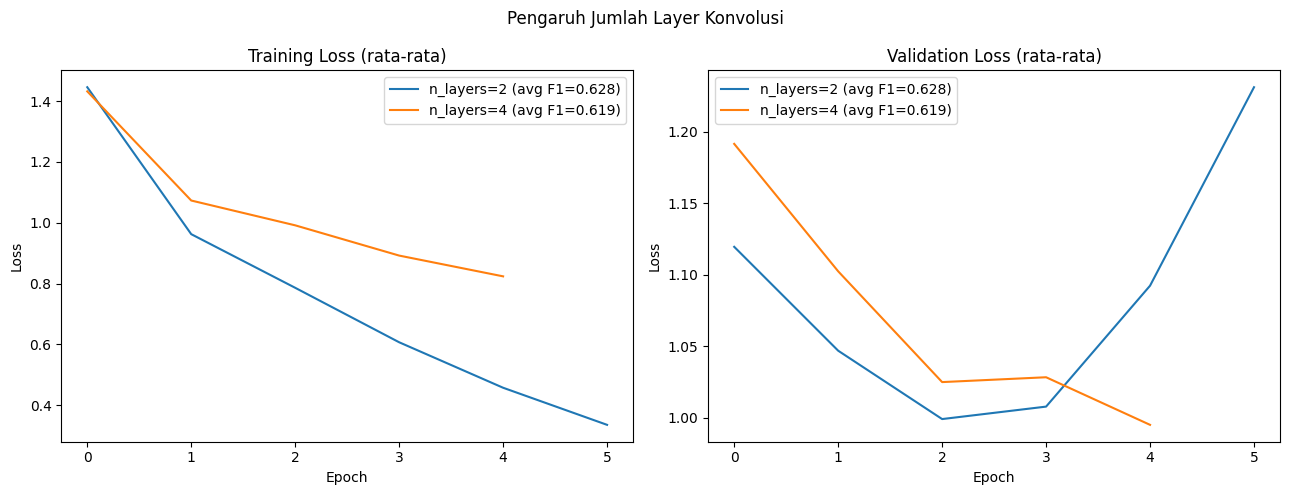

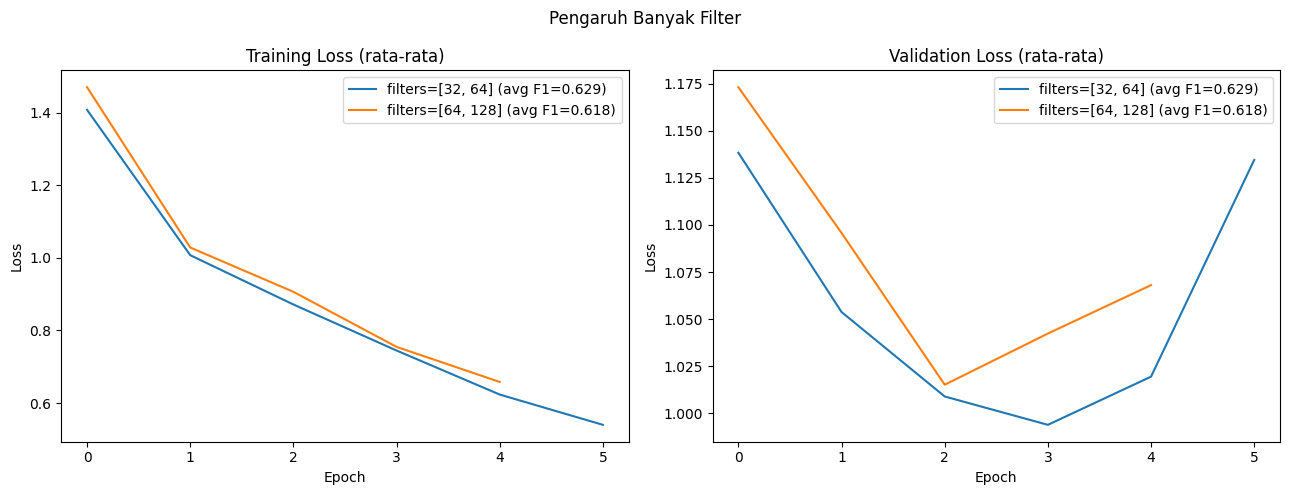

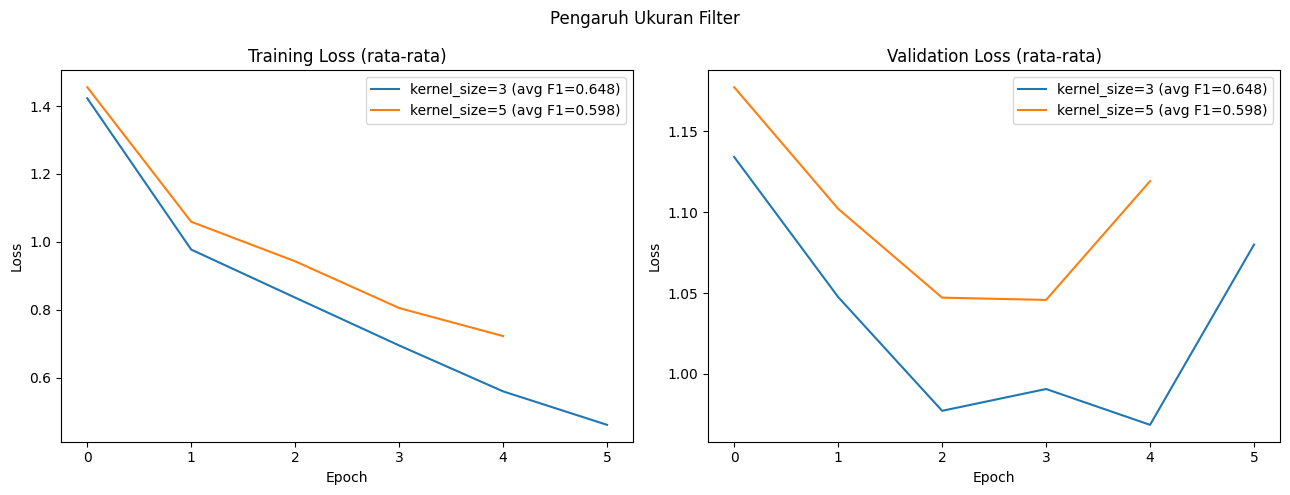

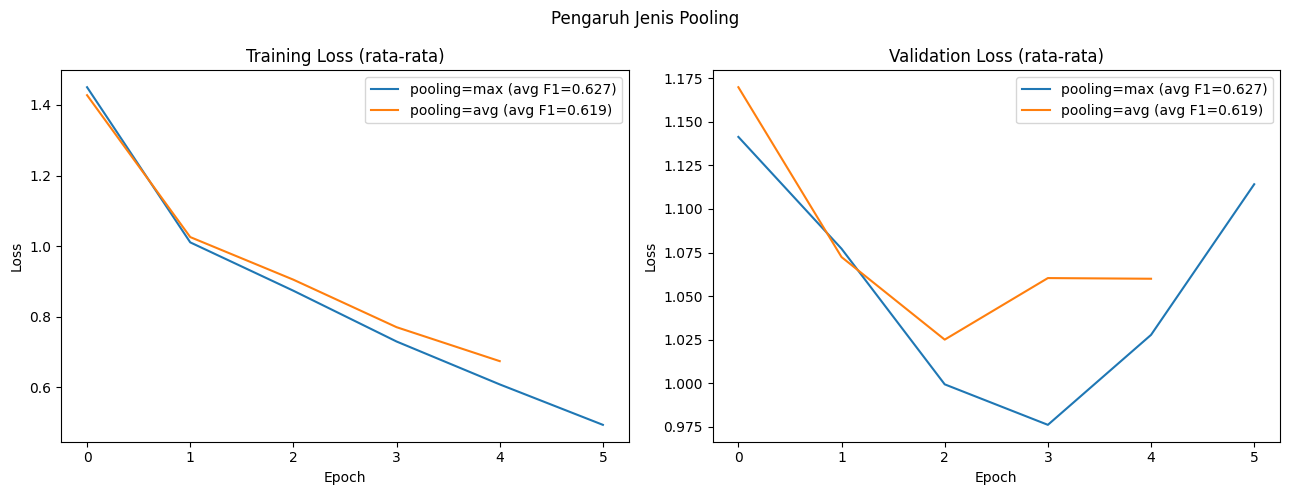

In [11]:
def plot_hp_effect(results, key, values, title):
    has_history = any(len(r['history'].get('loss', [])) > 0 for r in results)

    if has_history:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        for val in values:
            subset       = [r for r in results if r['config'][key] == val]
            train_losses = [r['history']['loss'] for r in subset]
            val_losses   = [r['history']['val_loss'] for r in subset]
            min_len      = min(len(l) for l in train_losses)
            avg_train    = np.mean([l[:min_len] for l in train_losses], axis=0)
            avg_val      = np.mean([l[:min_len] for l in val_losses],   axis=0)
            avg_f1       = np.mean([r['test_f1'] for r in subset])
            label = f'{key}={val} (avg F1={avg_f1:.3f})'
            axes[0].plot(avg_train, label=label)
            axes[1].plot(avg_val,   label=label)
        axes[0].set_title('Training Loss (rata-rata)')
        axes[1].set_title('Validation Loss (rata-rata)')
        for ax in axes:
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.legend()
        fig.suptitle(title)
        plt.tight_layout()
        plt.show()

plot_hp_effect(results, 'n_layers', [2, 4], 'Pengaruh Jumlah Layer Konvolusi')
plot_hp_effect(results, 'filters', [[32, 64], [64, 128]], 'Pengaruh Banyak Filter')
plot_hp_effect(results, 'kernel_size', [3, 5], 'Pengaruh Ukuran Filter')
plot_hp_effect(results, 'pooling', ['max', 'avg'], 'Pengaruh Jenis Pooling')

### Pengaruh jumlah layer konvolusi

Rata-rata test F1 arsitektur 2 layer (`0.6357`) sedikit lebih tinggi dari 4 layer (`0.6282`), namun model terbaik secara individual berasal dari 4 layer (model [08], `F1=0.6720`). Arsitektur yang lebih dalam berpotensi mengekstrak fitur lebih kaya, tetapi lebih sensitif terhadap kombinasi *hyperparameter* lain dan lebih rentan *underfitting* pada data training yang terbatas.

### Pengaruh banyak filter per layer konvolusi
Filter `[32, 64]` menghasilkan rata-rata test F1 `0.6339`, sedikit lebih baik dari `[64, 128]` yang mencapai `0.6300`. Filter lebih besar memiliki kapasitas lebih tinggi namun membutuhkan lebih banyak data untuk konvergen, sehingga kurang optimal pada skala *sampling* yang digunakan.

### Pengaruh ukuran filter (kernel size)
`kernel_size=3` secara konsisten lebih unggul dengan rata-rata test F1 `0.6436` dibanding `kernel_size=5` yang hanya `0.6078`. Kernel 3×3 lebih efektif pada gambar resolusi 64×64 karena lebih sesuai menangkap fitur lokal diskriminatif, sedangkan kernel 5×5 yang lebih besar cenderung mengaburkan detail penting.

### Pengaruh jenis pooling layer
Max pooling lebih unggul dengan rata-rata test F1 `0.6378` dibanding average pooling `0.6261`. Max pooling mempertahankan aktivasi paling menonjol sehingga lebih efektif menangkap fitur tekstur dan tepi yang menjadi pembeda antar kelas pada dataset ini.

# 4. Error Analysis
## Eksperimen dan Evaluasi

Bagian ini bertujuan mengevaluasi implementasi *forward propagation from scratch* dan menganalisis pengaruh setiap *hyperparameter*. Arsitektur terbaik dari Bagian 3 dijalankan menggunakan implementasi *scratch* berbasis NumPy dan hasilnya dibandingkan dengan Keras. Selain itu, dilakukan perbandingan antara Conv2D (*shared parameter*) dan LocallyConnected2D (*non-shared parameter*) untuk menganalisis dampak parameter sharing terhadap performa dan efisiensi model.

In [12]:
x_test = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)
y_test = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
print('Test set:', x_test.shape)

Test set: (3000, 64, 64, 3)


In [13]:
best_cfg = best['config']
keras_best = build_cnn(best_cfg['n_layers'], best_cfg['filters'], best_cfg['kernel_size'], best_cfg['pooling'])
keras_best.compile(optimizer='adam', loss='sparse_categorical_crossentropy', jit_compile=False)
keras_best.load_weights(best['weight_path'])

y_pred_keras = np.argmax(keras_best.predict(x_test, verbose=1), axis=1)
f1_keras = f1_score(y_test, y_pred_keras, average='macro')
print(f'Keras Test macro F1: {f1_keras:.4f}')

I0000 00:00:1778938919.490076    2810 cuda_dnn.cc:461] Loaded cuDNN version 90300


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Keras Test macro F1: 0.6724


In [14]:
def build_scratch_model(keras_model):
    layers = []
    for keras_layer in keras_model.layers:
        name = keras_layer.name
        if 'conv2d' in name and 'locally' not in name:
            w, b = keras_layer.get_weights()
            cfg  = keras_layer.get_config()
            layer = Conv2DScratch(
                filters=keras_layer.filters,
                kernel_size=keras_layer.kernel_size,
                strides=keras_layer.strides,
                padding=cfg['padding'],
                activation=cfg['activation'],
            )
            layer.kernel, layer.bias = w.astype(np.float32), b.astype(np.float32)
            layers.append(layer)
        elif 'max_pooling' in name:
            layers.append(MaxPooling2DScratch(pool_size=keras_layer.pool_size, strides=keras_layer.strides))
        elif 'average_pooling' in name:
            layers.append(AveragePooling2DScratch(pool_size=keras_layer.pool_size, strides=keras_layer.strides))
        elif 'flatten' in name:
            layers.append(FlattenScratch())
        elif 'dense' in name:
            w, b = keras_layer.get_weights()
            cfg  = keras_layer.get_config()
            layer = Dense(n_neurons=keras_layer.units, activation=cfg['activation'])
            layer.weights, layer.biases = w.astype(np.float32), b.astype(np.float32)
            layers.append(layer)

    return Sequential(layers)

def predict_in_batches(model, x, batch_size=32):
    results = []
    for i in range(0, len(x), batch_size):
        batch = x[i:i + batch_size].astype(np.float32)
        results.append(model.predict(batch))
    return np.concatenate(results, axis=0)

scratch_model = build_scratch_model(keras_best)
scratch_model.build((1, *x_test.shape[1:]))

y_pred_scratch = np.argmax(predict_in_batches(scratch_model, x_test), axis=1)
f1_scratch = f1_score(y_test, y_pred_scratch, average='macro')
print(f'Scratch (Conv2D) Test macro F1: {f1_scratch:.4f}')
print(f'Selisih Keras dengan Scratch: {abs(f1_keras - f1_scratch):.6f}')


Scratch (Conv2D) Test macro F1: 0.6724
Selisih Keras dengan Scratch: 0.000000


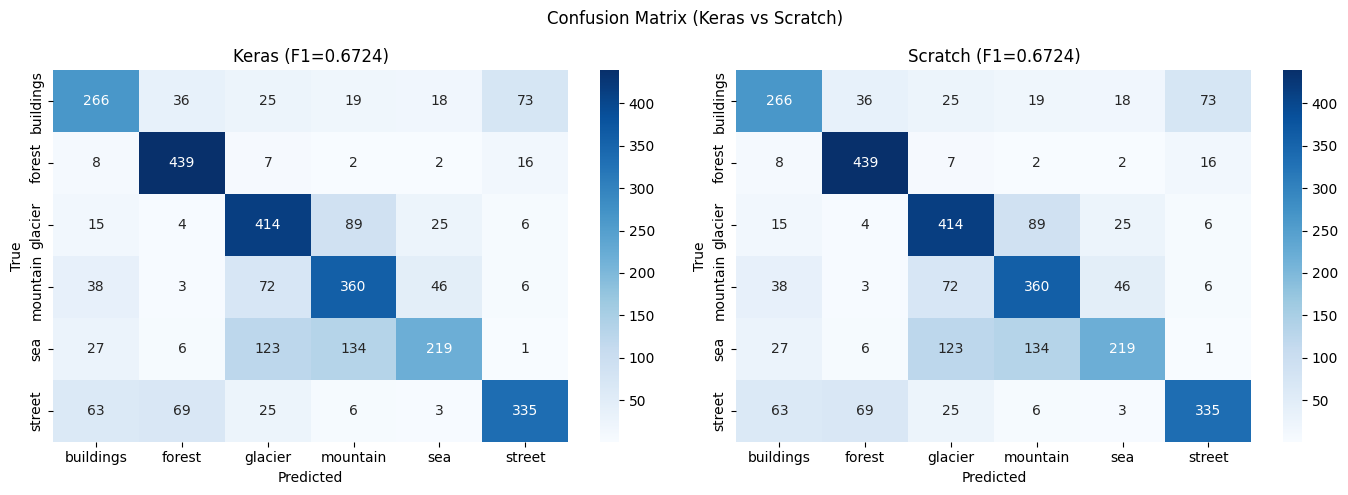

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_keras, y_pred_scratch], [f'Keras (F1={f1_keras:.4f})', f'Scratch (F1={f1_scratch:.4f})']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.suptitle('Confusion Matrix (Keras vs Scratch)')
plt.tight_layout()
plt.show()

### Perbandingan Keras dengan Forward Propagation From Scratch

Implementasi *from scratch* menghasilkan test macro F1 `0.6724`, identik dengan Keras. Hasil ini memvalidasi bahwa seluruh operasi forward propagation konvolusi, ReLU, max pooling, flatten, dan dense telah terimplementasi dengan benar.

In [16]:
def build_locally_connected(n_layers, filters, kernel_size, pooling):
    filters_ext = (filters * n_layers)[:n_layers]
    Pool = tf_keras.layers.MaxPooling2D if pooling == 'max' else tf_keras.layers.AveragePooling2D
    model = tf_keras.Sequential()
    model.add(tf_keras.layers.Input(shape=(*IMAGE_SIZE, 3)))
    for i in range(n_layers):
        model.add(tf_keras.layers.LocallyConnected2D(filters_ext[i], kernel_size, activation='relu'))
        if i % 2 == 1 or i == n_layers - 1:
            model.add(Pool(pool_size=2))
    model.add(tf_keras.layers.Flatten())
    model.add(tf_keras.layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

lc_weight_path  = WEIGHTS_DIR / 'model_locally_connected.weights.h5'
lc_history_path = WEIGHTS_DIR / 'lc_history.json'

lc_train_ds = train_ds.unbatch().batch(8)
lc_val_ds   = val_ds.unbatch().batch(8)

lc_model = build_locally_connected(2, [8, 16], best_cfg['kernel_size'], best_cfg['pooling'])
lc_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=False)

print(f'Parameter Conv2D (shared)   : {keras_best.count_params():,}')
print(f'Parameter LocallyConnected  : {lc_model.count_params():,}')

if lc_weight_path.exists():
    lc_model(tf.zeros((1, *IMAGE_SIZE, 3)))
    import h5py
    with h5py.File(str(lc_weight_path), 'r') as f:
        for layer in lc_model.layers:
            key = f'layers/{layer.name}/vars'
            if key not in f:
                continue
            vs = f[key]
            for var, idx in zip(layer.trainable_weights, sorted(vs.keys())):
                var.assign(vs[idx][:])

    if lc_history_path.exists():
        with open(lc_history_path) as f:
            _hist_dict = json.load(f)
        class _H:
            history = _hist_dict
        lc_history = _H()
    else:
        lc_history = None
else:
    lc_history = lc_model.fit(
        lc_train_ds, validation_data=lc_val_ds, epochs=EPOCHS,
        callbacks=[tf_keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=1,
    )
    lc_model.save_weights(str(lc_weight_path))
    with open(lc_history_path, 'w') as f:
        json.dump(lc_history.history, f, indent=2, default=float)

y_pred_lc = np.argmax(lc_model.predict(x_test, batch_size=8, verbose=0), axis=1)
f1_lc = f1_score(y_test, y_pred_lc, average='macro')
print(f'LocallyConnected2D Test macro F1: {f1_lc:.4f}')

Parameter Conv2D (shared)   : 412,614
Parameter LocallyConnected  : 5,152,262
Epoch 1/10


I0000 00:00:1778939189.918375    2813 service.cc:153] XLA service 0x7e4ccc348400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778939189.919325    2813 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 12.6.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.3.0)
I0000 00:00:1778939189.971263    2813 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778939190.197559    2813 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 [==============================] - 444s 1s/step - loss: 1.5459 - accuracy: 0.3713 - val_loss: 1.3400 - val_accuracy: 0.4542
Epoch 2/10
200/200 [==============================] - 68s 337ms/step - loss: 1.3073 - accuracy: 0.4963 - val_loss: 1.2914 - val_accuracy: 0.4896
Epoch 3/10
200/200 [==============================] - 68s 336ms/step - loss: 1.2322 - accuracy: 0.5125 - val_loss: 1.2842 - val_accuracy: 0.4958
Epoch 4/10
200/200 [==============================] - 70s 348ms/step - loss: 1.1651 - accuracy: 0.5544 - val_loss: 1.2327 - val_accuracy: 0.5417
Epoch 5/10
200/200 [==============================] - 69s 344ms/step - loss: 1.1072 - accuracy: 0.5838 - val_loss: 1.1753 - val_accuracy: 0.5437
Epoch 6/10
200/200 [==============================] - 68s 338ms/step - loss: 1.0362 - accuracy: 0.6112 - val_loss: 1.1559 - val_accuracy: 0.5771
Epoch 7/10
200/200 [==============================] - 67s 335ms/step - loss: 0.9970 - accuracy: 0.6344 - val_loss: 1.1787 - val_accuracy: 0.552

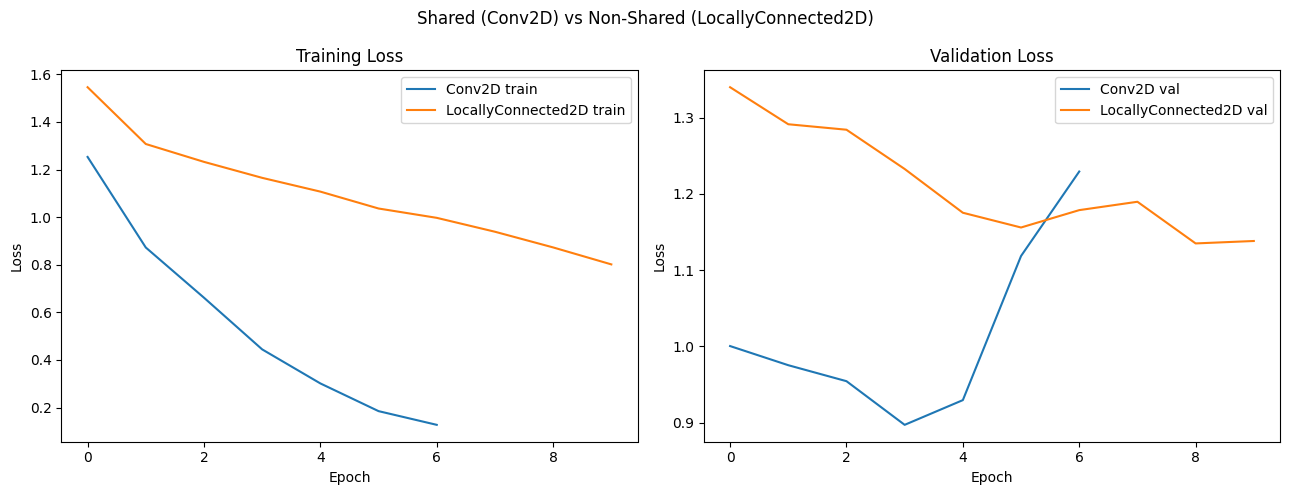


Perbandingan Shared vs Non-Shared
Conv2D (shared) - F1: 0.6724 | params: 412,614
LocallyConnected2D - F1: 0.5094 | params: 5,152,262

Perbandingan Keras vs Scratch
Keras (Conv2D) - F1: 0.6724
Scratch (Conv2D) - F1: 0.6724
Selisih : 0.000000


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(best['history']['loss'], label=f'Conv2D train')
axes[1].plot(best['history']['val_loss'], label=f'Conv2D val')

if lc_history is not None:
    axes[0].plot(lc_history.history['loss'], label=f'LocallyConnected2D train')
    axes[1].plot(lc_history.history['val_loss'], label=f'LocallyConnected2D val')
else:
    axes[0].plot([], [], label='LocallyConnected2D train (loaded)')
    axes[1].plot([], [], label='LocallyConnected2D val (loaded)')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
axes[0].set_title('Training Loss')
axes[1].set_title('Validation Loss')
fig.suptitle('Shared (Conv2D) vs Non-Shared (LocallyConnected2D)')
plt.tight_layout()
plt.show()

print('\nPerbandingan Shared vs Non-Shared')
print(f'Conv2D (shared) - F1: {f1_keras:.4f} | params: {keras_best.count_params():,}')
print(f'LocallyConnected2D - F1: {f1_lc:.4f} | params: {lc_model.count_params():,}')
print(f'\nPerbandingan Keras vs Scratch')
print(f'Keras (Conv2D) - F1: {f1_keras:.4f}')
print(f'Scratch (Conv2D) - F1: {f1_scratch:.4f}')
print(f'Selisih : {abs(f1_keras - f1_scratch):.6f}')

### Perbandingan Shared (Conv2D) dengan Non-Shared (LocallyConnected2D)

Conv2D dengan *parameter sharing* jauh lebih unggul meski memiliki parameter ~12,5 kali lebih sedikit. *Weight sharing* memberikan *inductive bias* yang sesuai untuk data visual, sehingga model lebih mudah dilatih dengan data terbatas. LocallyConnected2D dengan kapasitas parameter yang jauh lebih besar justru sulit konvergen dan mengalami degradasi performa.

# Visualisasi Fitur CNN

## 1. Intermediate Feature Maps

Visualisasi untuk kelas: buildings


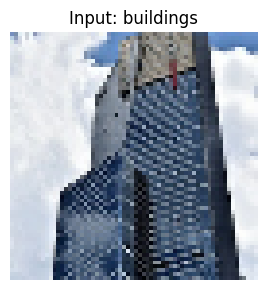

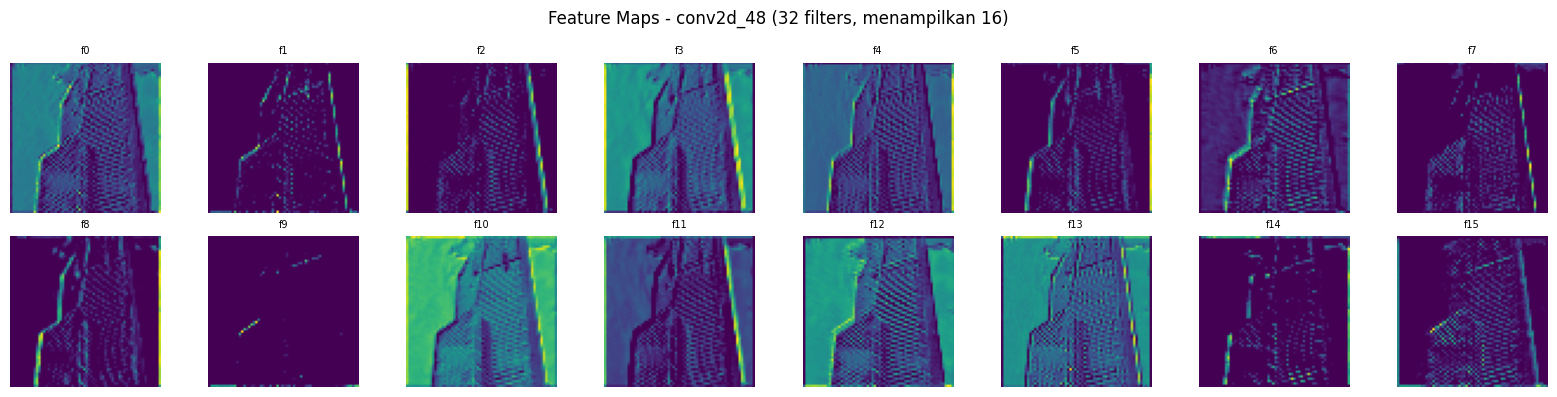

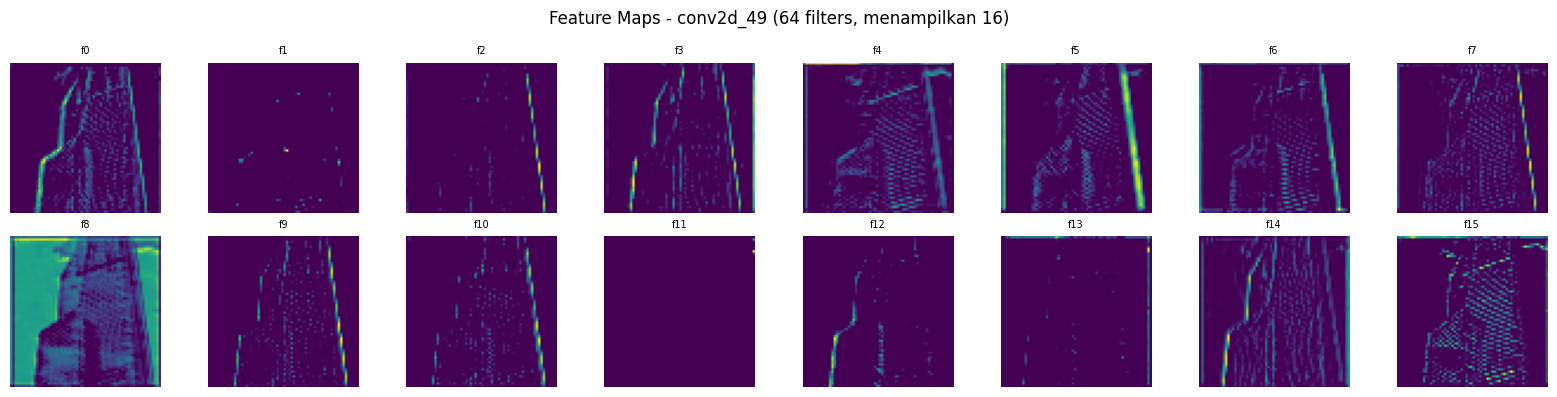

In [18]:
sample_imgs, sample_labels = [], []
for cls_idx in range(NUM_CLASSES):
    idx = np.where(y_test == cls_idx)[0][0]
    sample_imgs.append(x_test[idx])
    sample_labels.append(y_test[idx])

img = sample_imgs[0]
label = sample_labels[0]

print(f'Visualisasi untuk kelas: {CLASS_NAMES[label]}')

x = tf.constant(np.expand_dims(img, axis=0), dtype=tf.float32)
feature_maps = []
conv_layer_names = []
current = x
for layer in keras_best.layers:
    current = layer(current)
    if 'conv2d' in layer.name:
        feature_maps.append(current.numpy())
        conv_layer_names.append(layer.name)

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f'Input: {CLASS_NAMES[label]}')
plt.axis('off')
plt.tight_layout()
plt.show()

for layer_name, fmap in zip(conv_layer_names, feature_maps):
    n_show = min(16, fmap.shape[-1])
    fig, axes = plt.subplots(2, n_show // 2, figsize=(16, 4))
    fig.suptitle(f'Feature Maps - {layer_name} ({fmap.shape[-1]} filters, menampilkan {n_show})')
    for idx, ax in enumerate(axes.flat):
        ax.imshow(fmap[0, :, :, idx], cmap='viridis')
        ax.set_title(f'f{idx}', fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Visualisasi intermediate feature maps dilakukan pada satu contoh gambar kelas buildings menggunakan arsitektur terbaik (4 layer, filters=[32,64], kernel_size=3, max pooling). Setiap layer konvolusi memiliki jumlah filter berbeda, dan ditampilkan hingga 16 filter per layer. Pada layer konvolusi awal, feature maps cenderung merespons fitur-fitur primitif seperti tepi, gradien warna, dan tekstur kasar yang masih mudah diinterpretasikan secara visual. Semakin dalam layer-nya, feature maps menjadi semakin abstrak. Beberapa filter mengaktivasi pola yang sangat spesifik sedangkan yang lain tampak hampir tidak aktif, menunjukkan terjadinya *feature specialization*, dengan masing-masing filter belajar mendeteksi konsep visual yang berbeda.

## 2. Grad-CAM

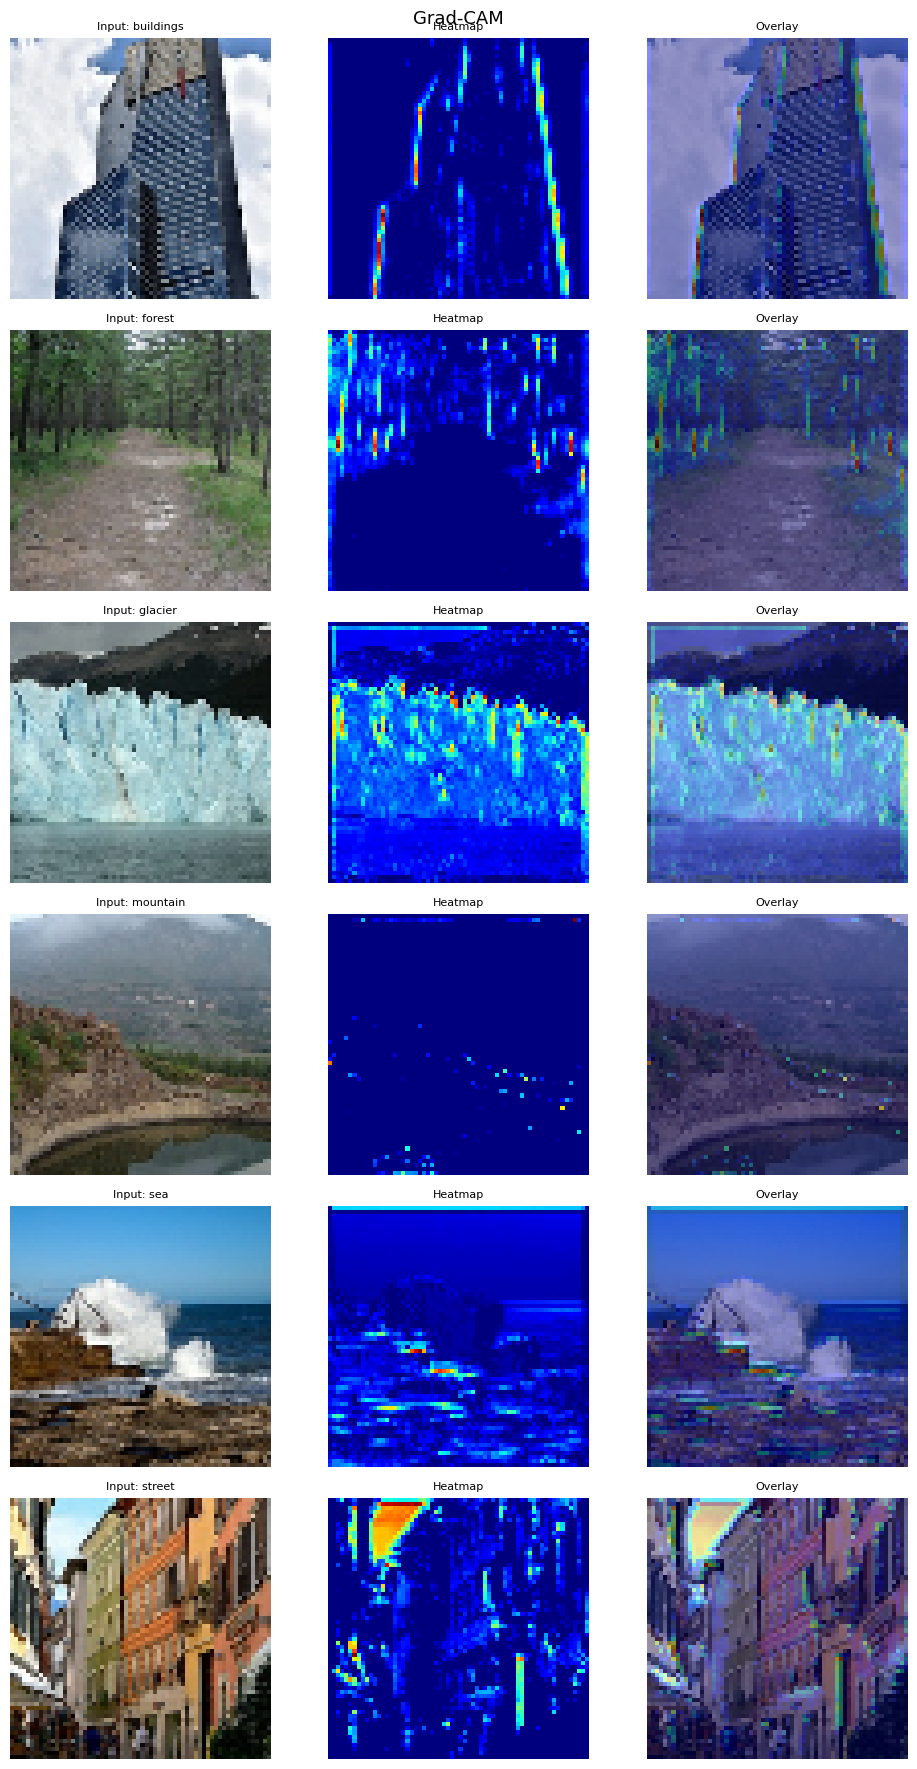

In [19]:
import matplotlib.cm as cm

def compute_gradcam(model, img_array, class_idx=None):
    last_conv_name = [l.name for l in model.layers if 'conv2d' in l.name][-1]
    last_conv_idx  = next(i for i, l in enumerate(model.layers) if l.name == last_conv_name)
    current = tf.cast(img_array, tf.float32)
    for layer in model.layers[:last_conv_idx + 1]:
        current = layer(current)
    conv_output_np = current.numpy()
    conv_var = tf.Variable(conv_output_np, dtype=tf.float32)

    with tf.GradientTape() as tape:
        out = conv_var
        for layer in model.layers[last_conv_idx + 1:]:
            out = layer(out)
        if class_idx is None:
            class_idx = int(tf.argmax(out[0]))
        class_score = out[:, class_idx]

    grads = tape.gradient(class_score, conv_var)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()

    heatmap = np.dot(conv_output_np[0], pooled_grads)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap, int(class_idx)


def overlay_gradcam(img, heatmap, alpha=0.4):
    H, W = img.shape[:2]
    heatmap_resized = np.array(
        tf.image.resize(heatmap[..., np.newaxis], (H, W))
    ).squeeze()
    colormap = plt.colormaps['jet']
    heatmap_colored = colormap(heatmap_resized)[:, :, :3]
    overlay = (1 - alpha) * img + alpha * heatmap_colored
    return np.clip(overlay, 0, 1)


fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(10, NUM_CLASSES * 3))
fig.suptitle('Grad-CAM', fontsize=13)

for cls_idx, (img, label) in enumerate(zip(sample_imgs, sample_labels)):
    img_input = np.expand_dims(img, axis=0).astype(np.float32)

    heatmap, pred_class = compute_gradcam(keras_best, img_input, class_idx=label)
    overlay = overlay_gradcam(img, heatmap)

    axes[cls_idx, 0].imshow(img)
    axes[cls_idx, 0].set_title(f'Input: {CLASS_NAMES[label]}', fontsize=8)
    axes[cls_idx, 0].axis('off')

    axes[cls_idx, 1].imshow(heatmap, cmap='jet')
    axes[cls_idx, 1].set_title('Heatmap', fontsize=8)
    axes[cls_idx, 1].axis('off')

    axes[cls_idx, 2].imshow(overlay)
    axes[cls_idx, 2].set_title('Overlay', fontsize=8)
    axes[cls_idx, 2].axis('off')

plt.tight_layout()
plt.show()

Grad-CAM divisualisasikan untuk satu contoh gambar dari masing-masing kelas dengan menggunakan layer konvolusi terakhir sebagai referensi. Heatmap yang dihasilkan menunjukkan *region* pada gambar yang paling berkontribusi terhadap prediksi kelas yang benar. Secara umum, model cenderung memfokuskan perhatian pada area yang secara semantik relevan, misalnya pada kelas buildings dan street model mengaktivasi area struktur buatan manusia, sedangkan pada forest aktivasi terpusat pada area tekstur dedaunan. Hal ini menunjukkan bahwa model CNN tidak hanya menghafal pola global, tetapi telah belajar merespons fitur visual yang bermakna dan diskriminatif untuk masing-masing kelas.